# Parameterized Alpha Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Three cases of preprocessing for the final `alpha` diversity analysis

## Setup and Imports

In [1]:
from pathlib import Path

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")
%matplotlib inline 

INFO | nb_multiple_studies | Hello from mgnify_methods


In [2]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
    clean_tax_row,
)
# All low level functions are imported from the momics package
from momics.utils import load_and_clean

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calculate_min_rarefaction_depth,
)

from mgnify_methods.metacomp.diversity import alpha_diversity_analysis
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    process_analysis_metadata,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
    align_emobon_metadata,
    add_meta,
)

from mgnify_methods import TaxonomyTable, AbundanceTable
import mgnify_methods.paper_modules as pm

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [3]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2019': ['MGYS00006607', 'mgnify_data/ERP124431_taxonomy_abundances_SSU_v5.0.tsv'],
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        # 'Tara': ['MGYS00000492', 'mgnify_data/ERP003634_taxonomy_abundances_SSU_v5.0.tsv'],
        'Biscay': ['MGYS00006682', 'mgnify_data/SRP334933_taxonomy_abundances_SSU_v5.0.tsv'],
        'Baltic': ['MGYS00006678', 'mgnify_data/ERP140185_taxonomy_abundances_SSU_v5.0.tsv'],
        'BBMO': ['MGYS00006675', 'mgnify_data/ERP122219_taxonomy_abundances_SSU_v5.0.tsv'],
        'Svalbard': ['MGYS00003725', 'mgnify_data/ERP106348_taxonomy_abundances_SSU_v5.0.tsv'],
        'Helgoland': ['MGYS00006686', 'mgnify_data/ERP144826_taxonomy_abundances_SSU_v5.0.tsv'],
        'Fram': ['MGYS00006714', 'mgnify_data/ERP151329_taxonomy_abundances_SSU_v5.0.tsv'],

    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        "indicators": {
            "superkingdom": "sk__",
            "kingdom": "k__",
            "phylum": "p__",
            "class": "c__",
            "order": "o__",
            "family": "f__",
            "genus": "g__",
            "species": "s__",
            },
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
            'rarefy': False,  # Rarefy samples to minimum depth before alpha diversity analysis
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': False,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['OSD2018', 'OSD2019', 'Sola', 'Biscay', 'Baltic', 'BBMO', 'Svalbard', 'Helgoland', 'Fram']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260217_1950
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260217_1950/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta, samples_meta = pm.load_mgnify_meta(ANALYSIS_CACHE, ds)

INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_methods.utils.io | Analysis Svalbard has 159 samples.
INFO | mgnify_methods.utils.io | Analysis Helgoland has 357 samples.
INFO | mgnify_methods.utils.io | Analysis Fram has 205 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_methods.utils.io | Analysis Svalbard has 159 samples.
INFO | mgnify_m

## Load EMO-BON data

In [6]:
root_folder = Path('../').resolve()

assets_folder = root_folder / 'assets'
data_folder = root_folder / 'data'

def get_valid_samples():
    df_valid = pd.read_csv(
        root_folder / 'data/shipment_b1b2_181.csv'
    )
    return df_valid

valid_samples = get_valid_samples()

# High level function from the momics.utils module
emobon_meta, mgf_parquet_dfs = load_and_clean(valid_samples=valid_samples)
emobon_meta['study_tag'] = 'EMO-BON'
emobon_meta['sample_type'] = 'prok'
emobon_meta = align_emobon_metadata(emobon_meta)

# keep only ssu
ssu = mgf_parquet_dfs['ssu'].copy()

del mgf_parquet_dfs

In [7]:
ssu_filt = fill_taxonomy_placeholders(ssu, CONFIG['taxonomy']['ranks'])
ssu_filt = pivot_taxonomic_data(ssu_filt)


# unify taxonomic information to the MGnify
ssu_filt = ssu_filt.reset_index()
ssu_filt['taxonomic_concat'] = ssu_filt['taxonomic_concat'].apply(clean_tax_row)
ssu_filt = ssu_filt.reset_index()
# unify column and index names
ssu_filt.drop(columns=['ncbi_tax_id', 'index'], inplace=True)
ssu_filt = ssu_filt.rename(columns={
    'taxonomic_concat': '#SampleID',
})
ssu_filt.set_index('#SampleID', inplace=True)

## Merge metadata

In [8]:
samples_meta = pd.concat([emobon_meta, samples_meta], axis=0, sort=False)

## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===


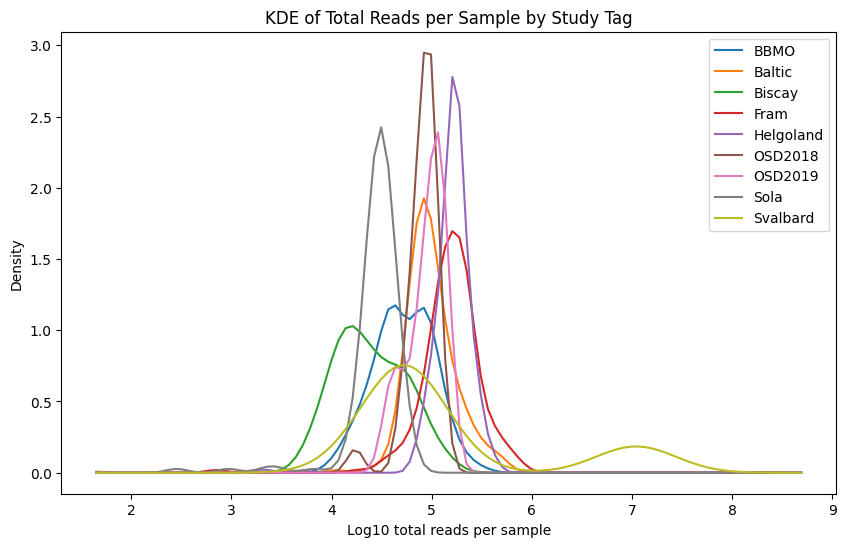

INFO | mgnify_methods.utils.io | Dropping 119 samples with less than 25000 reads: ['ERR4674146', 'ERR4674181', 'SRR10716900', 'SRR10716902', 'SRR10716915', 'SRR10716916', 'SRR10716928', 'SRR10716933', 'SRR10716938', 'SRR10716948', 'SRR10716962', 'SRR10716963', 'SRR10716966', 'SRR10716969', 'SRR10716974', 'SRR10716979', 'SRR10716983', 'SRR10716989', 'SRR10717005', 'SRR10716910', 'SRR10716970', 'SRR10716971', 'SRR10716985', 'SRR10716990', 'SRR10716950', 'SRR10716954', 'SRR10716972', 'SRR10716977', 'SRR10716988', 'SRR10716991', 'SRR10716995', 'SRR10716996', 'SRR10717002', 'SRR10717010', 'SRR10717023', 'SRR10717046', 'SRR10717050', 'SRR15678353', 'SRR15678354', 'SRR15678355', 'SRR15678361', 'SRR15678377', 'SRR15678381', 'SRR15678386', 'SRR15678389', 'SRR15678393', 'SRR15678359', 'SRR15678372', 'SRR15678376', 'SRR15678378', 'SRR15678380', 'SRR15678388', 'SRR15678391', 'SRR15678350', 'SRR15678351', 'SRR15678356', 'SRR15678373', 'SRR15678375', 'SRR15678379', 'SRR15678382', 'SRR15678387', 'SRR


Filtering samples with < 25000 reads: 119 samples to remove
Remaining analyses after filtering: 1921

=== Reads Distribution (Filtered) ===


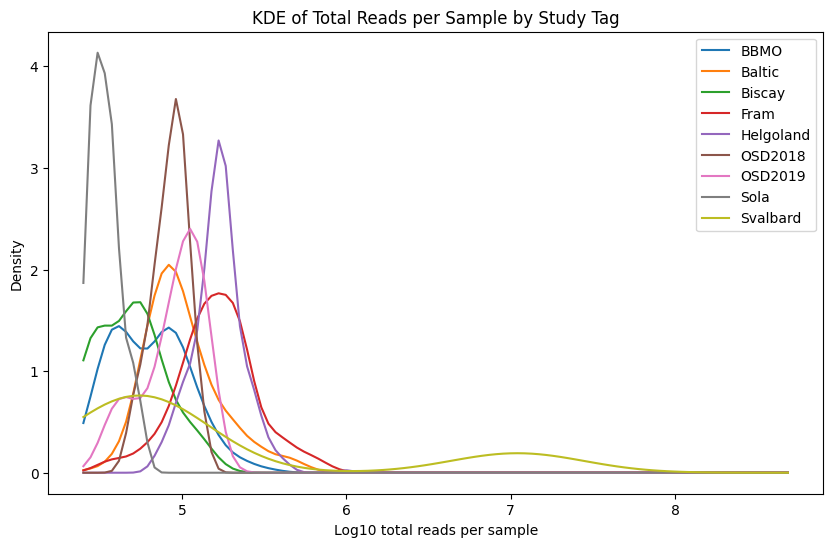

In [9]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(samples_meta, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    samples_meta = samples_meta[samples_meta.index != sample]

print(f"Remaining analyses after filtering: {len(samples_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_filtered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

## Load and Merge Taxonomy Data

In [10]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)
INFO | mgnify_methods.utils.io | Loaded OSD2019: (1708, 48)
INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded Biscay: (118, 52)
INFO | mgnify_methods.utils.io | Loaded Baltic: (4316, 665)
INFO | mgnify_methods.utils.io | Loaded BBMO: (2503, 249)
INFO | mgnify_methods.utils.io | Loaded Svalbard: (1505, 81)
INFO | mgnify_methods.utils.io | Loaded Helgoland: (2241, 165)
INFO | mgnify_methods.utils.io | Loaded Fram: (1428, 205)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (7265, 1810)


### Merge EMO-BON data

In [11]:
# merge ssu_filt and df_tax_summary on index
df_tax_summary = df_tax_summary.merge(
    ssu_filt,
    left_index=True,
    right_index=True,
    how='outer',
).fillna(0)
df_tax_summary.shape

(14393, 1991)

## Synchronize Metadata and Taxonomy Tables

In [12]:
# Remove samples not in metadata
df_tax_summary, samples_meta = filter_tax_summary(df_tax_summary, samples_meta)

# check data integrity
# assert_taxonomy_integrity(df_tax_summary, samples_meta)

INFO | mgnify_methods.utils.io | 
Before filtering: Taxonomy: 1991, metadata: 1921
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 1731
INFO | mgnify_methods.utils.io | Metadata samples after filtering: 1731
INFO | mgnify_methods.utils.io | 
Removing 604 taxa with all zero counts


## Convert to TaxonomyTable Format

In [13]:
del ssu_filt
del analysis_meta
del emobon_meta

In [15]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw
WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint32
INFO | mgnify_methods.tables.tables | Validating source: tax_processed



Taxonomy table ready: (563011, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [16]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta.query("sample_type == @sample_type").index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(sample_list)]

print(f"Filtered to {sample_type} samples: {len(sample_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 1731 samples
Filtered taxonomy table: (563011, 9)


## Taxonomic Overlap Analysis

In [ ]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, samples_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [17]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)
del taxonomy_table

In [19]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

In [21]:
## Here I need to remove rows which have undefined tax_level, basically ;p__; for example if tax_level is 'genus', I need to remove rows which have ';g__' but not ';s__' (species level is missing). This is because these undefined taxa can cause problems for the DESeq2 analysis later on, and they also don't provide useful information. I will keep rows which have defined taxonomic information at the selected level, even if they are missing information at lower levels. For example, if tax_level is 'family', I will keep rows which have ';f__' even if they are missing ';g__' and ';s__'.
tax_prefix = CONFIG['taxonomy']['indicators'][tax_level]
logger.info(f"Filtering out taxa with undefined {tax_level} (prefix '{tax_prefix}')")
logger.info(f"Abundance table before filtering {tax_level}: {abundance_table.shape}")
abundance_table = abundance_table[~abundance_table.index.str.contains(f";{tax_prefix};")]
logger.info(f"Abundance table after filtering {tax_level}: {abundance_table.shape}")

INFO | nb_multiple_studies | Filtering out taxa with undefined phylum (prefix 'p__')
INFO | nb_multiple_studies | Abundance table before filtering phylum: (264, 1731)
INFO | nb_multiple_studies | Abundance table after filtering phylum: (258, 1731)
INFO | nb_multiple_studies | Abundance table before filtering phylum: (264, 1731)
INFO | nb_multiple_studies | Abundance table after filtering phylum: (258, 1731)


## Apha diversity analysis
- Needs to be on counts

**Three cases**
1. No additional preprocessing
2. Only removing singletons
3. Only rarefaction

Both removing singletons and rarefaction is not recommended

In [28]:
tax_level = CONFIG['taxonomy']['analysis_level']

### Case 1, no preprocessing

INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1731 samples, 264 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'EMO-BON': 181, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260211_1903/alpha_diversity_phylum_no_processing.csv


Calculated diversity for 1731 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
BBMO        212.0  1.102  0.301  0.123  0.911  1.108  1.324  1.835   212.0   
Baltic      656.0  1.727  0.348  0.348  1.486  1.716  1.962  2.623   656.0   
Biscay       25.0  0.695  0.318  0.136  0.465  0.693  0.877  1.319    25.0   
EMO-BON     181.0  2.038  0.504  0.485  1.628  2.108  2.417  2.860   181.0   
Fram        203.0  1.489  0.238  0.804  1.350  1.520  1.643  2.049   203.0   
Helgoland   164.0  1.398  0.480  0.139  1.149  1.450  1.758  2.298   164.0   
OSD2018      58.0  1.458  0.285  0.506  1.301  1.490  1.647  1.926    58.0   
OSD2019      48.0  1.352  0.219  0.843  1.178  1.386  1.503  1.765    48.0   
Sola        107.0  1.347  0.165  0.901  1.238  1.380  1.477  1.682   107.0   
Svalbard     77.0  1.327  0.478  0.146  0.987  1.296  1.634  2.588    77.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
BBMO       0.525  0.146  0.037  0.424  0.550  0.633  0.802         212.0   
Baltic     0.722  0.109  0.112  0.670  0.748  0.792  0.906         656.0   
Biscay     0.394  0.167  0.059  0.277  0.419  0.514  0.658          25.0   
EMO-BON    0.730  0.135  0.179  0.633  0.751  0.836  0.917         181.0   
Fram       0.679  0.070  0.424  0.645  0.699  0.726  0.798         203.0   
Helgoland  0.594  0.185  0.046  0.532  0.642  0.730  0.839         164.0   
OSD2018    0.675  0.116  0.222  0.627  0.698  0.749  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.393  0.573  0.625  0.672  0.742         107.0   
Svalbard   0.586  0.173  0.049  0.481  0.633  0.707  0.879          77.0   

                                                           chao1          \
             mean     std   min    25%   50%   75%    max  count    mean   
study_tag                                                                  
BBMO       26.099   8.506  11.0  20.00  25.0  33.0   52.0  212.0  31.676   
Baltic     41.855  12.062   7.0  35.00  41.0  48.0   84.0  656.0  46.296   
Biscay      7.320   4.507   2.0   4.00   7.0  10.0   19.0   25.0   7.770   
EMO-BON    85.315  19.327  41.0  70.00  85.0  99.0  131.0  181.0  97.515   
Fram       39.862   7.424  20.0  35.50  40.0  44.0   58.0  203.0  48.478   
Helgoland  48.555  12.897  21.0  44.00  53.0  58.0   73.0  164.0  53.411   
OSD2018    38.759  13.334  11.0  30.25  37.5  48.0   71.0   58.0  46.718   
OSD2019    42.792  16.856  15.0  30.00  44.5  56.0   80.0   48.0  51.263   
Sola       32.720   8.882  19.0  27.00  31.0  36.0   70.0  107.0  45.650   
Svalbard   32.195  11.143  12.0  23.00  34.0  40.0   56.0   77.0  38.120   

                                                           
              std    min     25%     50%      75%     max  
study_tag                                                  
BBMO       12.832  11.00  22.830  29.100   40.062   87.75  
Baltic     14.171   7.00  37.688  44.550   53.600   95.00  
Biscay      4.976   2.00   4.000   7.000   11.000   22.00  
EMO-BON    22.974  46.50  81.200  96.750  113.750  151.50  
Fram       13.166  21.00  41.000  47.111   55.000  135.00  
Helgoland  14.433  23.25  45.425  56.125   62.312  107.00  
OSD2018    17.644  11.00  34.775  46.071   55.375  114.50  
OSD2019    21.412  17.50  34.025  54.814   63.000  113.50  
Sola       16.775  22.20  33.000  42.000   52.750  100.00  
Svalbard   15.191  12.00  27.500  39.000   44.600  103.60

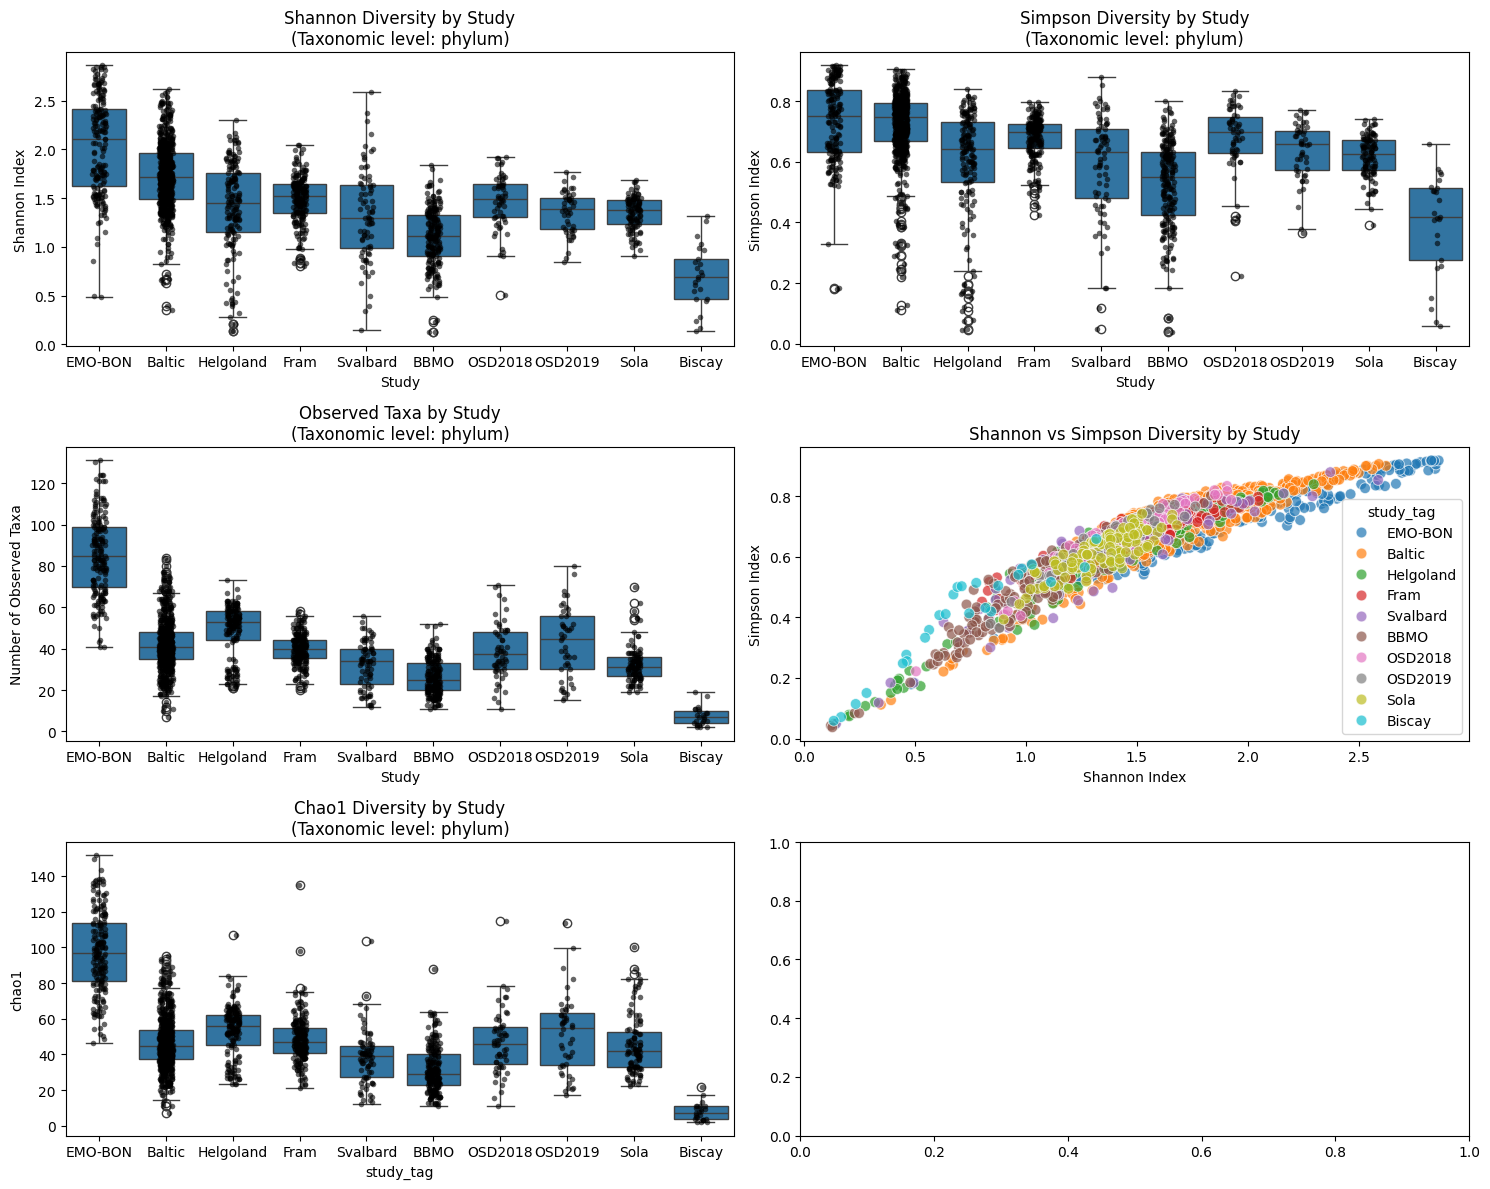

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=665.753, p=0.0000, epsilon²=0.382
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=511.334, p=0.0000, epsilon²=0.292
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=825.113, p=0.0000, epsilon²=0.474
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=696.308, p=0.0000, epsilon²=0.399


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,EMO-BON vs Baltic,Pairwise MW,81547.0,1.338402e-14,0.392299,-0.373585,0.373585,665.752622,1.587002e-137,0.381611,4.149045e-13
1,shannon,EMO-BON vs Helgoland,Pairwise MW,24193.0,5.138681e-24,0.658088,-0.630036,0.630036,665.752622,1.587002e-137,0.381611,2.004086e-22
2,shannon,EMO-BON vs Fram,Pairwise MW,30230.0,9.092700e-28,0.588588,-0.645483,0.645483,665.752622,1.587002e-137,0.381611,3.637080e-26
3,shannon,EMO-BON vs Svalbard,Pairwise MW,11759.0,2.467634e-18,0.812745,-0.687451,0.687451,665.752622,1.587002e-137,0.381611,9.130245e-17
4,shannon,EMO-BON vs BBMO,Pairwise MW,36473.0,1.617363e-53,1.000242,-0.901022,0.901022,665.752622,1.587002e-137,0.381611,7.116397e-52
...,...,...,...,...,...,...,...,...,...,...,...,...
175,chao1,OSD2018 vs Sola,Pairwise MW,3352.0,3.963515e-01,4.071429,-0.080245,0.080245,696.307886,4.301248e-144,0.399365,1.000000e+00
176,chao1,OSD2018 vs Biscay,Pairwise MW,1441.5,1.179779e-12,39.071429,-0.988276,0.988276,696.307886,4.301248e-144,0.399365,3.067426e-11
177,chao1,OSD2019 vs Sola,Pairwise MW,2987.5,1.048836e-01,12.814286,-0.163357,0.163357,696.307886,4.301248e-144,0.399365,9.425782e-01
178,chao1,OSD2019 vs Biscay,Pairwise MW,1195.0,4.784461e-12,47.814286,-0.991667,0.991667,696.307886,4.301248e-144,0.399365,1.148271e-10


In [29]:
CONFIG['output']['alpha_tag'] = 'no_processing'
summary_case1, df_case1, stats_case1 = alpha_diversity_analysis(
    abundance_table,
    samples_meta, CONFIG,
)

In [23]:
# stats_case1['AdjP'].hist()

### Case 2, remove singletons

INFO | nb_multiple_studies | Removed singletons per sample
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...


Removed 10 singleton features. Shape reduced from (264, 1731) → (254, 1731)


INFO | mgnify_methods.metacomp.diversity | Data: 1731 samples, 254 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'EMO-BON': 181, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260211_1903/alpha_diversity_phylum_remove_singletons.csv


Calculated diversity for 1731 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
BBMO        212.0  1.100  0.301  0.123  0.910  1.107  1.323  1.834   212.0   
Baltic      656.0  1.726  0.347  0.348  1.485  1.715  1.961  2.623   656.0   
Biscay       25.0  0.683  0.324  0.000  0.465  0.693  0.872  1.300    25.0   
EMO-BON     181.0  2.031  0.503  0.483  1.615  2.101  2.415  2.854   181.0   
Fram        203.0  1.488  0.238  0.803  1.349  1.519  1.642  2.048   203.0   
Helgoland   164.0  1.397  0.480  0.138  1.148  1.449  1.758  2.298   164.0   
OSD2018      58.0  1.456  0.285  0.506  1.297  1.488  1.645  1.923    58.0   
OSD2019      48.0  1.350  0.219  0.841  1.176  1.383  1.501  1.762    48.0   
Sola        107.0  1.344  0.165  0.898  1.234  1.376  1.472  1.678   107.0   
Svalbard     77.0  1.321  0.473  0.146  0.986  1.295  1.629  2.569    77.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
BBMO       0.525  0.146  0.037  0.424  0.550  0.633  0.802         212.0   
Baltic     0.722  0.109  0.112  0.670  0.748  0.792  0.906         656.0   
Biscay     0.391  0.172  0.000  0.276  0.415  0.514  0.656          25.0   
EMO-BON    0.730  0.135  0.179  0.633  0.751  0.836  0.917         181.0   
Fram       0.679  0.070  0.424  0.645  0.699  0.726  0.798         203.0   
Helgoland  0.594  0.185  0.046  0.532  0.642  0.730  0.839         164.0   
OSD2018    0.675  0.116  0.222  0.627  0.698  0.748  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.393  0.573  0.624  0.672  0.741         107.0   
Svalbard   0.586  0.173  0.049  0.481  0.633  0.707  0.879          77.0   

                                                            chao1          \
             mean     std   min    25%   50%    75%    max  count    mean   
study_tag                                                                   
BBMO       20.613   6.654  10.0  15.00  19.0  25.25   46.0  212.0  20.613   
Baltic     36.430  11.159   7.0  29.00  36.0  42.00   75.0  656.0  36.430   
Biscay      6.000   3.948   1.0   3.00   5.0   9.00   16.0   25.0   6.000   
EMO-BON    70.387  16.944  31.0  56.00  71.0  83.00  118.0  181.0  70.387   
Fram       32.424   6.187  16.0  29.00  33.0  36.00   50.0  203.0  32.424   
Helgoland  43.024  12.749  16.0  39.00  47.0  52.00   67.0  164.0  43.024   
OSD2018    30.724  12.185  11.0  22.25  28.0  38.75   61.0   58.0  30.724   
OSD2019    33.875  15.103  11.0  22.75  32.5  44.00   67.0   48.0  33.875   
Sola       22.879   6.533  13.0  19.00  22.0  26.00   54.0  107.0  22.879   
Svalbard   26.169  10.041   8.0  18.00  27.0  33.00   47.0   77.0  26.169   

                                                    
              std   min    25%   50%    75%    max  
study_tag                                           
BBMO        6.654  10.0  15.00  19.0  25.25   46.0  
Baltic     11.159   7.0  29.00  36.0  42.00   75.0  
Biscay      3.948   1.0   3.00   5.0   9.00   16.0  
EMO-BON    16.944  31.0  56.00  71.0  83.00  118.0  
Fram        6.187  16.0  29.00  33.0  36.00   50.0  
Helgoland  12.749  16.0  39.00  47.0  52.00   67.0  
OSD2018    12.185  11.0  22.25  28.0  38.75   61.0  
OSD2019    15.103  11.0  22.75  32.5  44.00   67.0  
Sola        6.533  13.0  19.00  22.0  26.00   54.0  
Svalbard   10.041   8.0  18.00  27.0  33.00   47.0

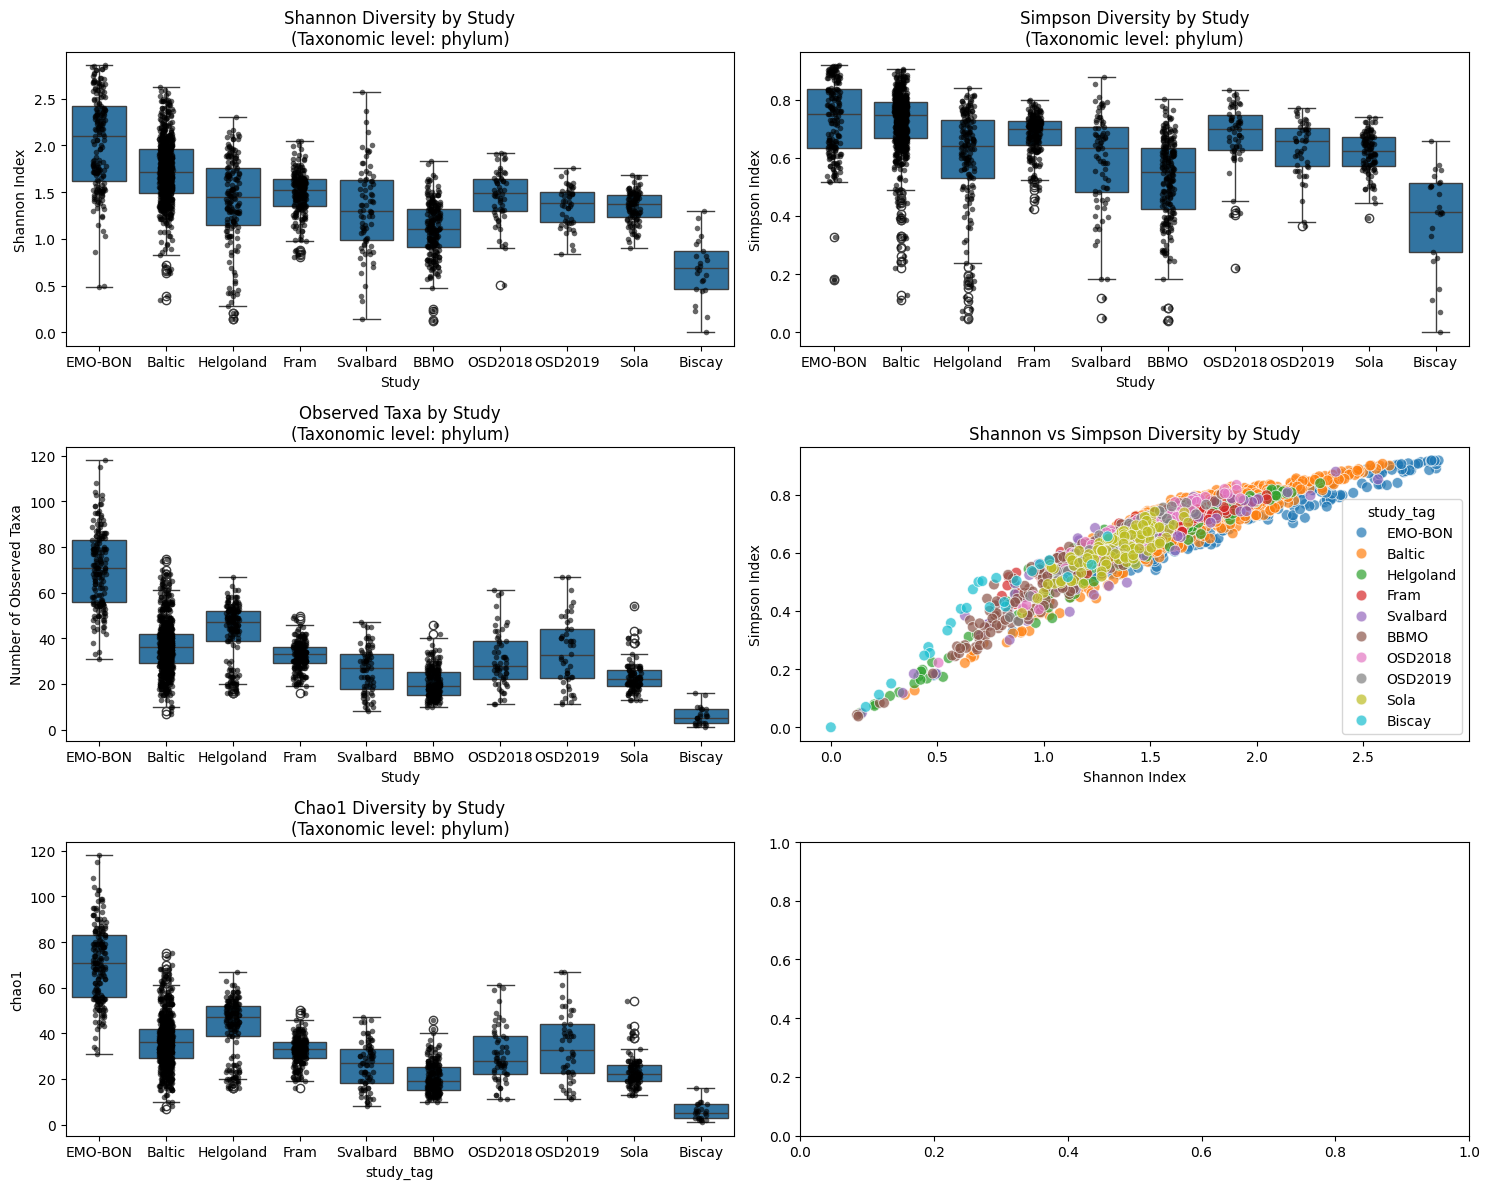

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=666.552, p=0.0000, epsilon²=0.382
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=511.922, p=0.0000, epsilon²=0.292
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=890.976, p=0.0000, epsilon²=0.512
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=890.976, p=0.0000, epsilon²=0.512


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,EMO-BON vs Baltic,Pairwise MW,81204.0,3.376779e-14,0.386526,-0.367808,0.367808,666.552152,1.068515e-137,0.382076,1.046801e-12
1,shannon,EMO-BON vs Helgoland,Pairwise MW,24138.0,9.409196e-24,0.652011,-0.626331,0.626331,666.552152,1.068515e-137,0.382076,3.669587e-22
2,shannon,EMO-BON vs Fram,Pairwise MW,30134.0,2.398023e-27,0.582365,-0.640258,0.640258,666.552152,1.068515e-137,0.382076,9.592090e-26
3,shannon,EMO-BON vs Svalbard,Pairwise MW,11784.0,1.647151e-18,0.806634,-0.691038,0.691038,666.552152,1.068515e-137,0.382076,6.094457e-17
4,shannon,EMO-BON vs BBMO,Pairwise MW,36438.0,2.618357e-53,0.994988,-0.899197,0.899197,666.552152,1.068515e-137,0.382076,1.152077e-51
...,...,...,...,...,...,...,...,...,...,...,...,...
175,chao1,OSD2018 vs Sola,Pairwise MW,4432.0,5.618096e-06,6.000000,-0.428295,0.428295,890.976055,5.441361e-186,0.512479,7.303524e-05
176,chao1,OSD2018 vs Biscay,Pairwise MW,1441.0,1.202973e-12,23.000000,-0.987586,0.987586,890.976055,5.441361e-186,0.512479,2.405946e-11
177,chao1,OSD2019 vs Sola,Pairwise MW,3675.5,1.793404e-05,10.500000,-0.431269,0.431269,890.976055,5.441361e-186,0.512479,1.972744e-04
178,chao1,OSD2019 vs Biscay,Pairwise MW,1187.0,9.012605e-12,27.500000,-0.978333,0.978333,890.976055,5.441361e-186,0.512479,1.712395e-10


In [30]:
abundance_table_alpha = abundance_table.copy()
abundance_table_alpha = remove_singletons_per_sample(abundance_table_alpha, skip_columns=0)
logger.info("Removed singletons per sample")

CONFIG['output']['alpha_tag'] = 'remove_singletons'
summary_case2, df_case2, stats_case2 = alpha_diversity_analysis(abundance_table_alpha, samples_meta, CONFIG)

### Case 3, Rarefy

INFO | nb_multiple_studies | 
=== Calculating Minimum Rarefaction Depth ===


Minimum rarefaction depth: 6


INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 6
INFO | nb_multiple_studies | Minimum rarefaction depth determined: 6 reads


Minimum rarefaction depth: 6


INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1731 samples, 264 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'EMO-BON': 181, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260211_1903/alpha_diversity_phylum_rarefied.csv


Calculated diversity for 1731 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
BBMO        212.0  0.758  0.386  0.000  0.451  0.693  1.011  1.792   212.0   
Baltic      656.0  1.075  0.370  0.000  0.868  1.011  1.330  1.792   656.0   
Biscay       25.0  0.455  0.260  0.000  0.451  0.451  0.637  0.868    25.0   
EMO-BON     181.0  1.147  0.437  0.000  0.868  1.242  1.561  1.792   181.0   
Fram        203.0  1.006  0.307  0.451  0.868  1.011  1.242  1.792   203.0   
Helgoland   164.0  0.854  0.417  0.000  0.451  0.868  1.242  1.792   164.0   
OSD2018      58.0  0.919  0.356  0.451  0.637  0.868  1.011  1.792    58.0   
OSD2019      48.0  0.980  0.384  0.000  0.637  1.011  1.242  1.792    48.0   
Sola        107.0  0.880  0.346  0.000  0.637  1.011  1.055  1.561   107.0   
Svalbard     77.0  0.851  0.437  0.000  0.451  0.868  1.242  1.561    77.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
BBMO       0.455  0.205  0.000  0.278  0.500  0.611  0.833         212.0   
Baltic     0.598  0.167  0.000  0.500  0.611  0.722  0.833         656.0   
Biscay     0.302  0.180  0.000  0.278  0.278  0.444  0.500          25.0   
EMO-BON    0.613  0.193  0.000  0.500  0.667  0.778  0.833         181.0   
Fram       0.581  0.135  0.278  0.500  0.611  0.667  0.833         203.0   
Helgoland  0.494  0.216  0.000  0.278  0.500  0.667  0.833         164.0   
OSD2018    0.532  0.163  0.278  0.444  0.500  0.611  0.833          58.0   
OSD2019    0.565  0.172  0.000  0.444  0.611  0.667  0.833          48.0   
Sola       0.517  0.178  0.000  0.444  0.611  0.639  0.778         107.0   
Svalbard   0.492  0.221  0.000  0.278  0.500  0.667  0.778          77.0   

                                                  chao1                     \
            mean    std  min  25%  50%  75%  max  count   mean    std  min   
study_tag                                                                    
BBMO       2.585  0.967  1.0  2.0  2.0  3.0  6.0  212.0  3.153  2.391  1.0   
Baltic     3.453  1.058  1.0  3.0  3.0  4.0  6.0  656.0  4.885  3.198  1.0   
Biscay     1.840  0.473  1.0  2.0  2.0  2.0  3.0   25.0  1.880  0.600  1.0   
EMO-BON    3.762  1.271  1.0  3.0  4.0  5.0  6.0  181.0  6.311  4.832  1.0   
Fram       3.177  0.889  2.0  3.0  3.0  4.0  6.0  203.0  4.011  2.197  2.0   
Helgoland  2.866  1.060  1.0  2.0  3.0  4.0  6.0  164.0  3.746  2.739  1.0   
OSD2018    3.017  1.000  2.0  2.0  3.0  3.0  6.0   58.0  3.954  2.957  2.0   
OSD2019    3.125  1.123  1.0  2.0  3.0  4.0  6.0   48.0  4.375  3.984  1.0   
Sola       2.879  0.866  1.0  2.0  3.0  3.0  5.0  107.0  3.458  1.699  1.0   
Svalbard   2.857  1.121  1.0  2.0  3.0  4.0  5.0   77.0  3.524  2.097  1.0   

                                    
           25%    50%    75%   max  
study_tag                           
BBMO       2.0  2.000  4.000  21.0  
Baltic     3.0  4.000  7.000  21.0  
Biscay     2.0  2.000  2.000   4.0  
EMO-BON    3.0  4.333  8.000  21.0  
Fram       3.0  3.000  4.333  21.0  
Helgoland  2.0  3.000  4.333  21.0  
OSD2018    2.0  3.000  4.000  21.0  
OSD2019    2.0  3.000  4.333  21.0  
Sola       2.0  3.000  4.000   8.0  
Svalbard   2.0  3.000  4.333   8.0

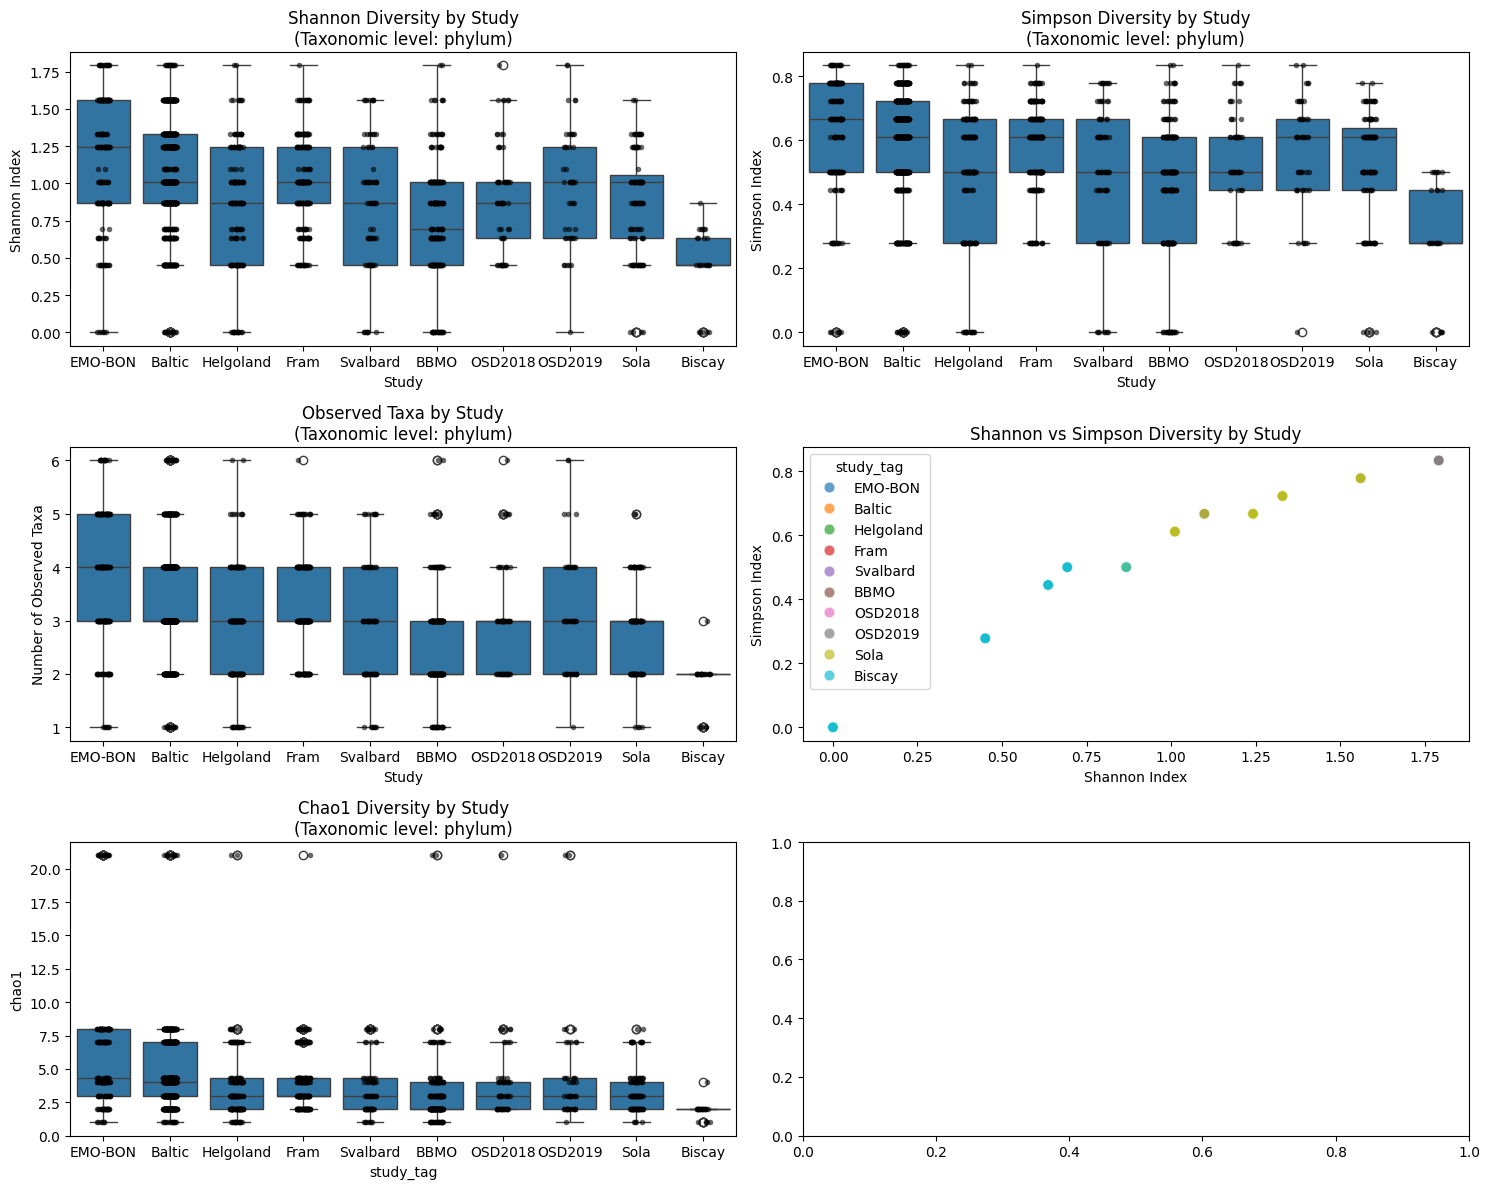

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=198.067, p=0.0000, epsilon²=0.110
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=191.344, p=0.0000, epsilon²=0.106
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=216.901, p=0.0000, epsilon²=0.121
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=215.448, p=0.0000, epsilon²=0.120


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,EMO-BON vs Baltic,Pairwise MW,66103.5,1.848262e-02,0.231049,-0.113453,0.113453,198.067047,8.420622e-38,0.109859,2.772393e-01
1,shannon,EMO-BON vs Helgoland,Pairwise MW,20402.5,1.449684e-09,0.374890,-0.374646,0.374646,198.067047,8.420622e-38,0.109859,5.508798e-08
2,shannon,EMO-BON vs Fram,Pairwise MW,22551.0,1.071055e-04,0.231049,-0.227499,0.227499,198.067047,8.420622e-38,0.109859,2.891849e-03
3,shannon,EMO-BON vs Svalbard,Pairwise MW,9525.0,2.600659e-06,0.374890,-0.366865,0.366865,198.067047,8.420622e-38,0.109859,8.062042e-05
4,shannon,EMO-BON vs BBMO,Pairwise MW,28562.0,4.119360e-17,0.549306,-0.488690,0.488690,198.067047,8.420622e-38,0.109859,1.812519e-15
...,...,...,...,...,...,...,...,...,...,...,...,...
175,chao1,OSD2018 vs Sola,Pairwise MW,3257.0,5.899930e-01,0.000000,-0.049629,0.049629,215.448469,1.895046e-41,0.119958,1.000000e+00
176,chao1,OSD2018 vs Biscay,Pairwise MW,1221.5,1.770532e-07,1.000000,-0.684828,0.684828,215.448469,1.895046e-41,0.119958,5.842756e-06
177,chao1,OSD2019 vs Sola,Pairwise MW,2762.5,4.406574e-01,0.000000,-0.075740,0.075740,215.448469,1.895046e-41,0.119958,1.000000e+00
178,chao1,OSD2019 vs Biscay,Pairwise MW,1006.0,6.079142e-07,1.000000,-0.676667,0.676667,215.448469,1.895046e-41,0.119958,1.884534e-05


In [31]:
abundance_table_alpha = abundance_table.copy()

logger.info("\n=== Calculating Minimum Rarefaction Depth ===")
MIN_DEPTH = calculate_min_rarefaction_depth(abundance_table_alpha)
logger.info(f"Minimum rarefaction depth determined: {MIN_DEPTH} reads")

abundance_table_alpha = rarefy_table(abundance_table_alpha, depth=MIN_DEPTH)


CONFIG['output']['alpha_tag'] = 'rarefied'
summary_case3, df_case3, stats_case3 = alpha_diversity_analysis(abundance_table_alpha, 
                                                   samples_meta,
                                                   CONFIG)

## Comparison between treatments
- construct table like this

| Pipeline     | Metric  | Δmedian | Effect size | p     | Direction |
| ------------ | ------- | ------- | ----------- | ----- | --------- |
| Raw counts   | Shannon | +0.11   | 0.28        | 0.001 | OSD>SOLA  |
| CLR filtered | Shannon | +0.08   | 0.21        | 0.02  | OSD>SOLA  |
| Rarefied     | Shannon | +0.10   | 0.26        | 0.003 | OSD>SOLA  |

- calculate delta medians and effect sizes


In [18]:
# summary_case1.head()

In [19]:
# df_case1.head()

In [20]:
# stats_case1.head()

### Combine per metric

In [19]:
df = pd.concat([stats_case1, stats_case2, stats_case3], axis=0)

shannon_stats = df[df['Metric'] == 'shannon']
try:
    shannon_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
except:
    pass
shannon_stats.head()


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,Baltic vs Helgoland,Pairwise MW,76216.0,1.395668e-16,0.284769,-0.416865,0.416865,537.716321,5.644921e-111,0.343748,4.466138e-15
1,shannon,Baltic vs Fram,Pairwise MW,94441.0,1.930931e-19,0.201448,-0.418374,0.418374,537.716321,5.644921e-111,0.343748,6.372071e-18
2,shannon,Baltic vs Svalbard,Pairwise MW,38897.0,8.476347e-15,0.418536,-0.540109,0.540109,537.716321,5.644921e-111,0.343748,2.542904e-13
3,shannon,Baltic vs BBMO,Pairwise MW,127628.0,7.527369e-75,0.598679,-0.835423,0.835423,537.716321,5.644921e-111,0.343748,2.709853e-73
4,shannon,Baltic vs OSD2018,Pairwise MW,27196.0,5.725441e-08,0.216859,-0.429563,0.429563,537.716321,5.644921e-111,0.343748,1.030579e-06


In [ ]:
simpson_stats = df[df['Metric'] == 'simpson']
simpson_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
simpson_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,simpson,0.698329,0.624790,0.073539,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Remove Singletons,simpson,0.698154,0.624490,0.073664,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Rarefied,simpson,0.697186,0.626994,0.070192,-0.457622,0.457622,4523.0,0.000001,OSD2018 > Sola


In [ ]:
otus_stats = df[df['Metric'] == 'observed_otus']
otus_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
otus_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,observed_otus,37.5,31.0,6.5,-0.321624,0.321624,4101.0,0.000656,OSD2018 > Sola
Remove Singletons,observed_otus,28.0,22.0,6.0,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,observed_otus,29.0,26.0,3.0,-0.193039,0.193039,3702.0,0.040747,OSD2018 > Sola


In [ ]:
chao1_stats = df[df['Metric'] == 'chao1']
chao1_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
chao1_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,chao1,46.071429,42.25,3.821429,-0.069771,0.069771,3319.5,0.460984,OSD2018 > Sola
Remove Singletons,chao1,28.000000,22.00,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,chao1,39.000000,35.00,4.000000,-0.078311,0.078311,3346.0,0.407834,OSD2018 > Sola


## Summary

In [ ]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic level: {CONFIG['taxonomy']['analysis_level']}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"\nPrimary grouping feature: {CONFIG['feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic level: phylum

Filtering:
  Min reads: 25000

Primary grouping feature: study_tag
